In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import  GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')


In [99]:
df=pd.read_excel("Flight_Fare.xlsx")

In [100]:
df1 =  df.copy()
#for future use

In [192]:
df.head()

,Total_Stops,Price,journey_day,journey_month,Dep_Time_Hour,Dep_Time_Min,Arrival_Time_Hour,Arrival_Time_Min,Dur_Hour,Dur_Minute,Route1,Route2,Route3,Route4,Route5
0,0,3897,24,3,22,20,1,10,2,50,0,13,29,13,5
1,2,7662,1,5,5,50,13,15,7,25,2,25,1,3,5
2,2,13882,9,6,9,25,4,25,19,0,3,32,4,5,5
3,1,6218,12,5,18,5,23,30,5,25,2,34,3,13,5
4,1,13302,1,3,16,50,21,35,4,45,0,34,8,13,5


In [72]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [101]:
df.shape

(10683, 11)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [103]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [104]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [ ]:
#Data Pre Processing and Cleaning

In [105]:
df.dropna(inplace=True)
df1.dropna(inplace=True)

In [106]:
df.duplicated().sum()

220

In [79]:
df[df.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


In [ ]:
# EDA And Feature Engineering

In [107]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])

In [108]:
df['journey_day']=df['Date_of_Journey'].dt.day
df['journey_month']=df['Date_of_Journey'].dt.month

In [109]:
df.drop('Date_of_Journey', axis=1, inplace=True)

In [110]:
df['Dep_Time_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Time_Min'] = df['Dep_Time'].dt.minute

In [111]:
df['Arrival_Time_Hour'] = df['Arrival_Time'].dt.hour
df['Arrival_Time_Min'] = df['Arrival_Time'].dt.minute

In [112]:
df.drop('Dep_Time', axis=1, inplace=True)
df.drop('Arrival_Time', axis=1, inplace=True)

In [113]:
duration=list(df['Duration'])
for i in range(len(duration)):
    if len(duration[i].split(' '))==2:
        pass
    else:
        if 'h' in duration[i]: # Check if duration contains only hour
             duration[i]=duration[i] + ' 0m' # Adds 0 minute
        else:
             duration[i]='0h '+ duration[i]

In [114]:
df['Duration'] = duration

In [115]:
df1['Duration'] = duration

In [116]:
# Extract hours and minutes from 'Duration' column using regex
df[['Dur_Hour', 'Dur_Minute']] = df['Duration'].str.extract(r'(\d+)h (\d+)m')

# Convert to integer type
df['Dur_Hour'] = df['Dur_Hour'].astype(int)
df['Dur_Minute'] = df['Dur_Minute'].astype(int)


In [117]:
df.drop('Duration', axis=1, inplace=True)
df.drop('Additional_Info', axis=1, inplace=True)

In [152]:
def plot(data, col):
    # Set style
    sns.set_style("whitegrid")

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Distribution plot
    sns.histplot(data[col], kde=True, color='skyblue', ax=ax1)
    ax1.set_title(f"Distribution of {col}", fontsize=16, fontweight='bold')
    ax1.set_xlabel("")
    ax1.set_ylabel("Frequency")

    # Box plot
    sns.boxplot(x=data[col], ax=ax2, palette="Set2")
    ax2.set_title(f"Boxplot of {col}", fontsize=16, fontweight='bold')
    ax2.set_xlabel(col)

    # Adjust layout
    plt.tight_layout()
    plt.show()


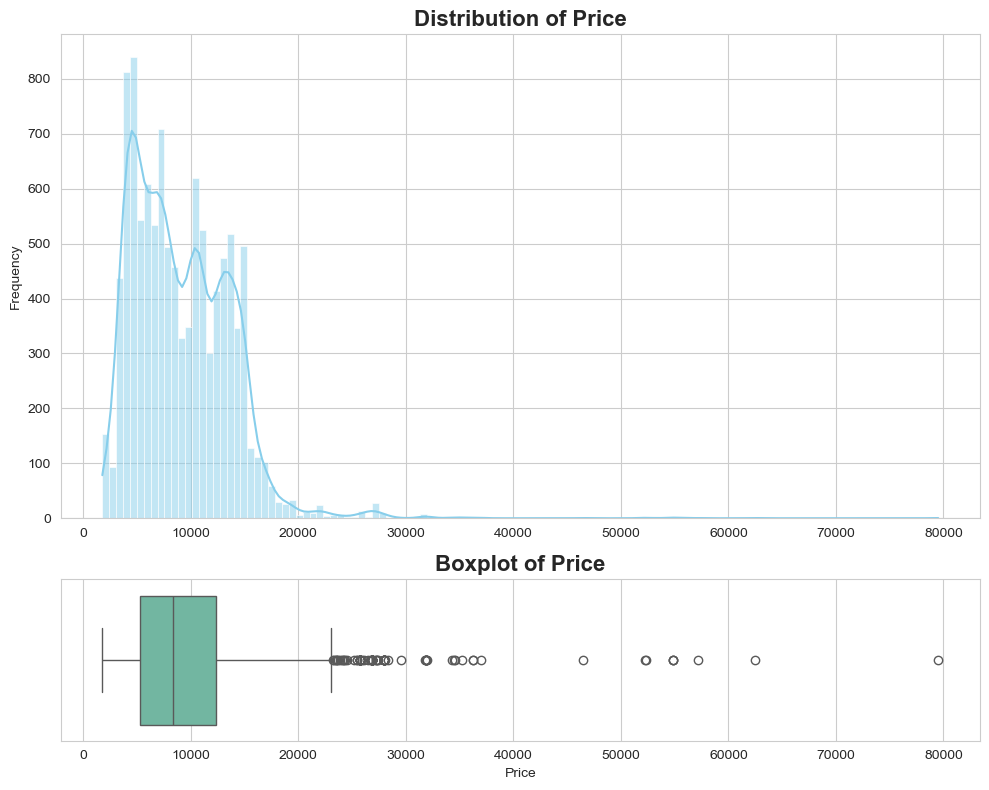

In [153]:
plot(df1,'Price')

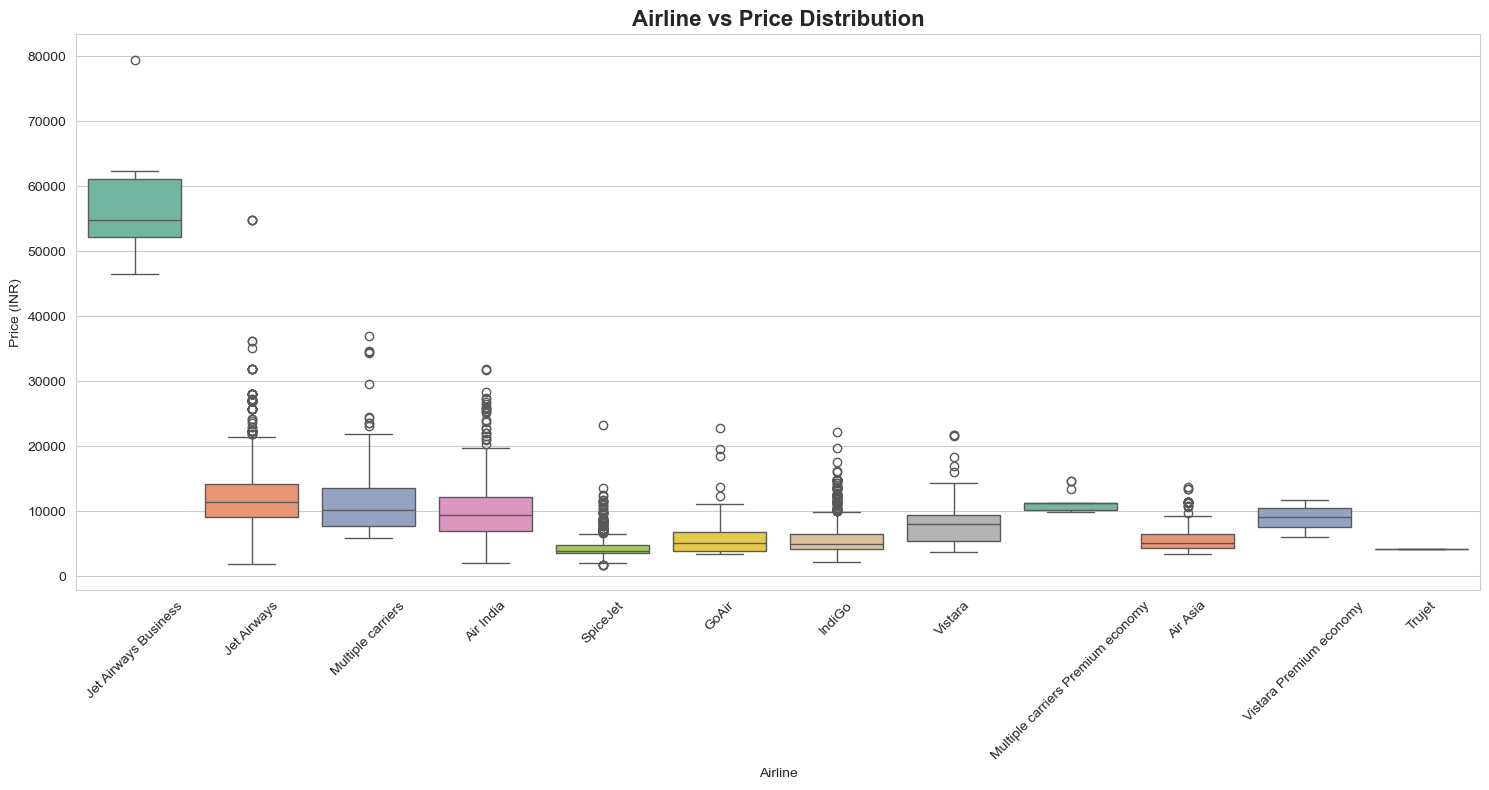

In [93]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    x='Airline',
    y='Price',
    data=df.sort_values('Price', ascending=False),
    palette='Set2'  # Try 'Set2', 'husl', 'coolwarm', 'Spectral', etc.
)

plt.title("Airline vs Price Distribution", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Price (INR)")
plt.xlabel("Airline")
plt.tight_layout()
plt.show()

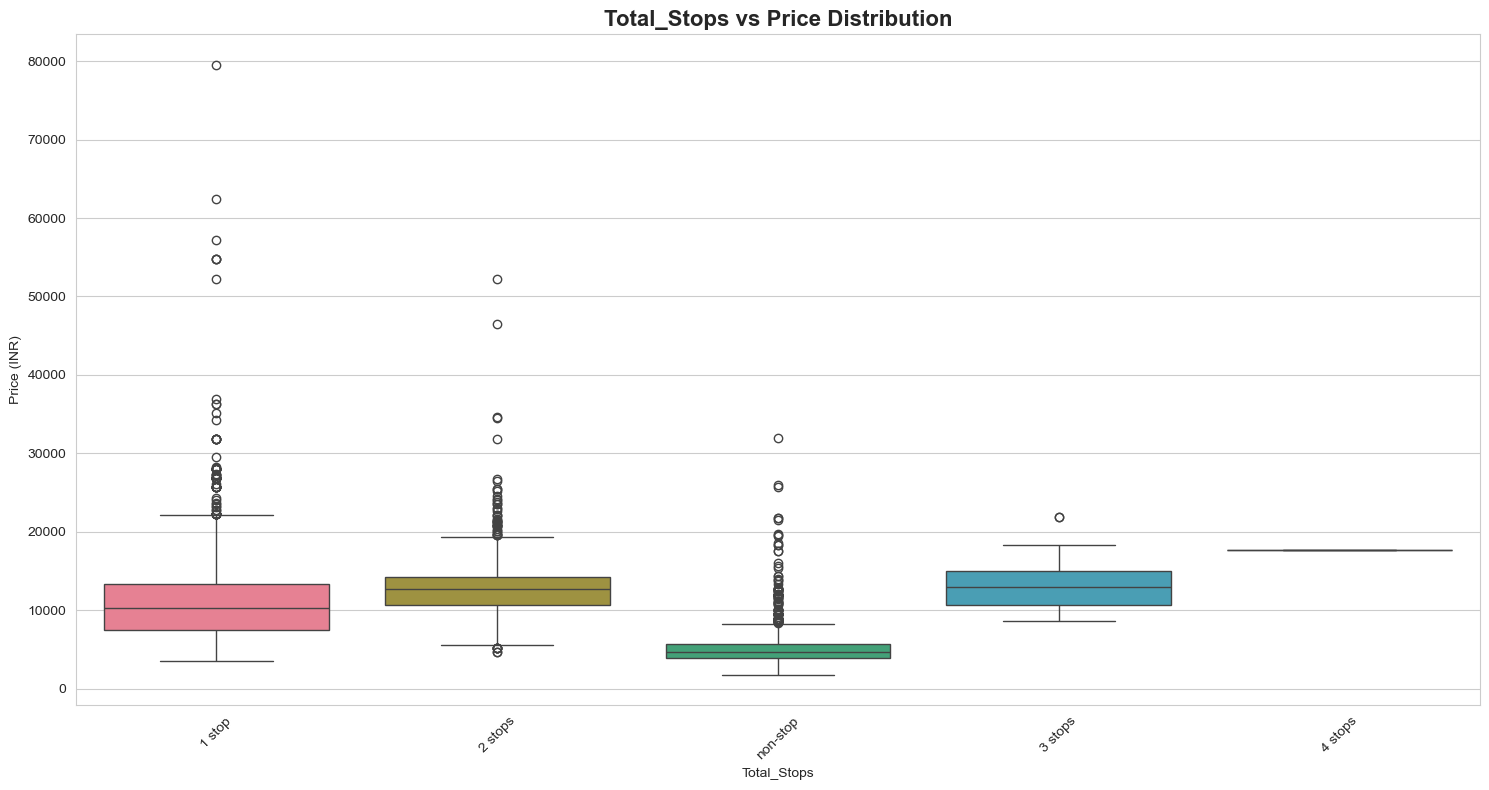

In [94]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Total_Stops',y='Price',data=df.sort_values('Price',ascending=False),palette='husl' )
plt.title("Total_Stops vs Price Distribution", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Price (INR)")
plt.xlabel("Total_Stops")
plt.tight_layout()
plt.show()

In [61]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


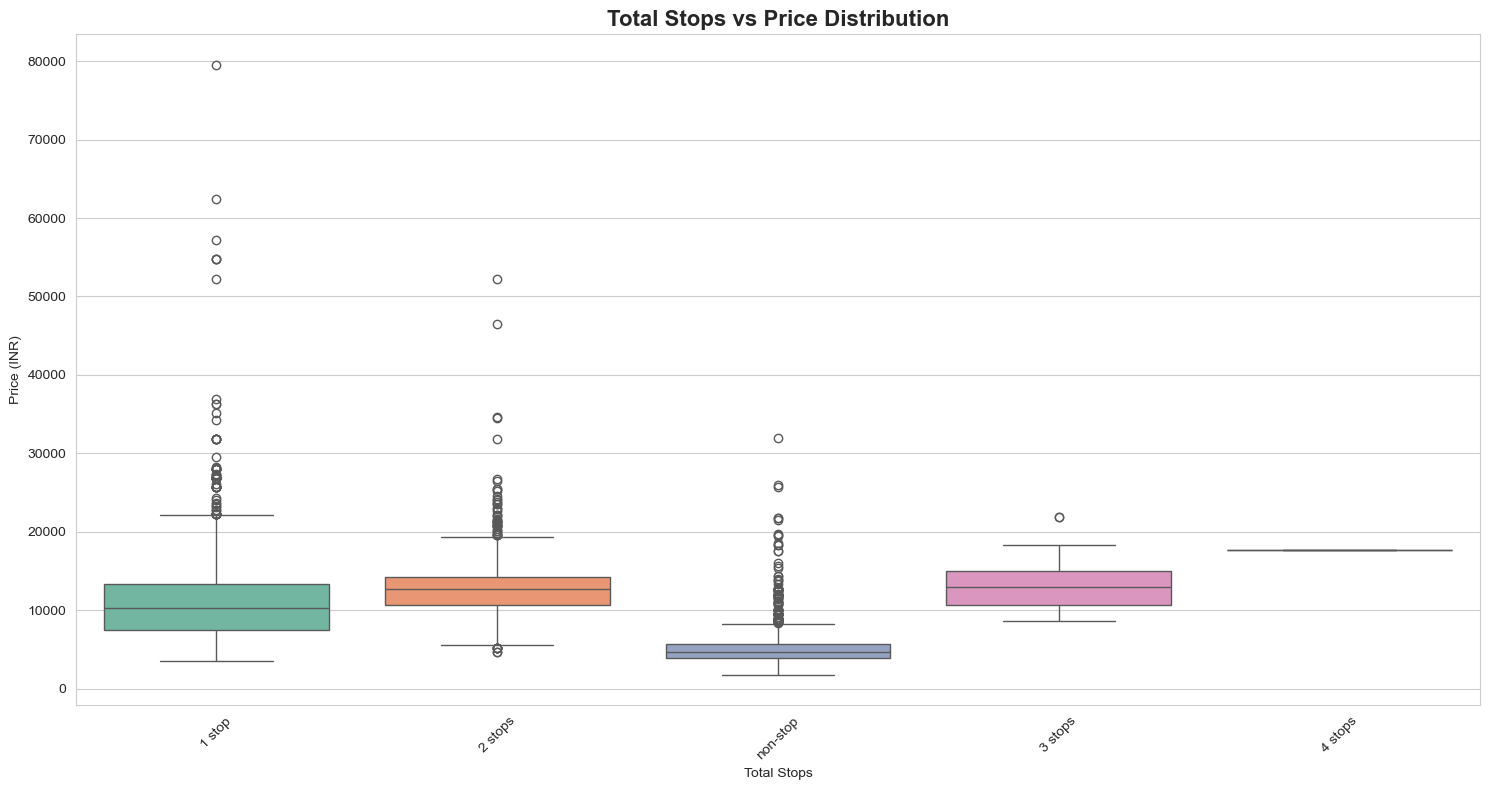

In [95]:
plt.figure(figsize=(15, 8))
sns.boxplot(
    x='Total_Stops',
    y='Price',
    data=df.sort_values('Price', ascending=False),
    palette='Set2'  # Try 'Set2', 'husl', 'coolwarm', 'Spectral', etc.
)

plt.title("Total Stops vs Price Distribution", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Price (INR)")
plt.xlabel("Total Stops")
plt.tight_layout()
plt.show()


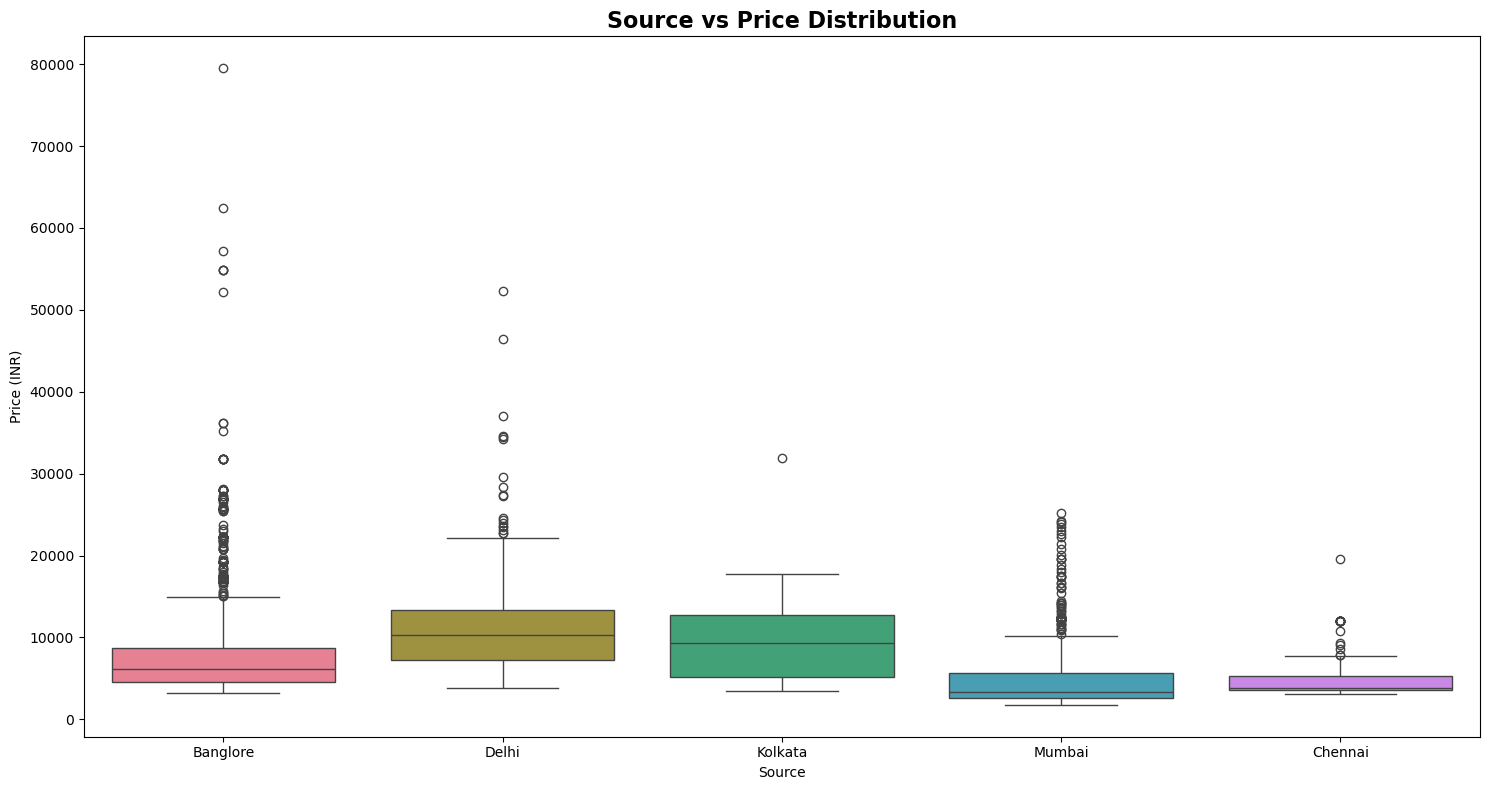

In [65]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Source',y='Price',data=df.sort_values('Price',ascending=False),palette='husl')
plt.title("Source vs Price Distribution", fontsize=16, fontweight='bold')
plt.ylabel("Price (INR)")
plt.xlabel("Source")
plt.tight_layout()
plt.show()

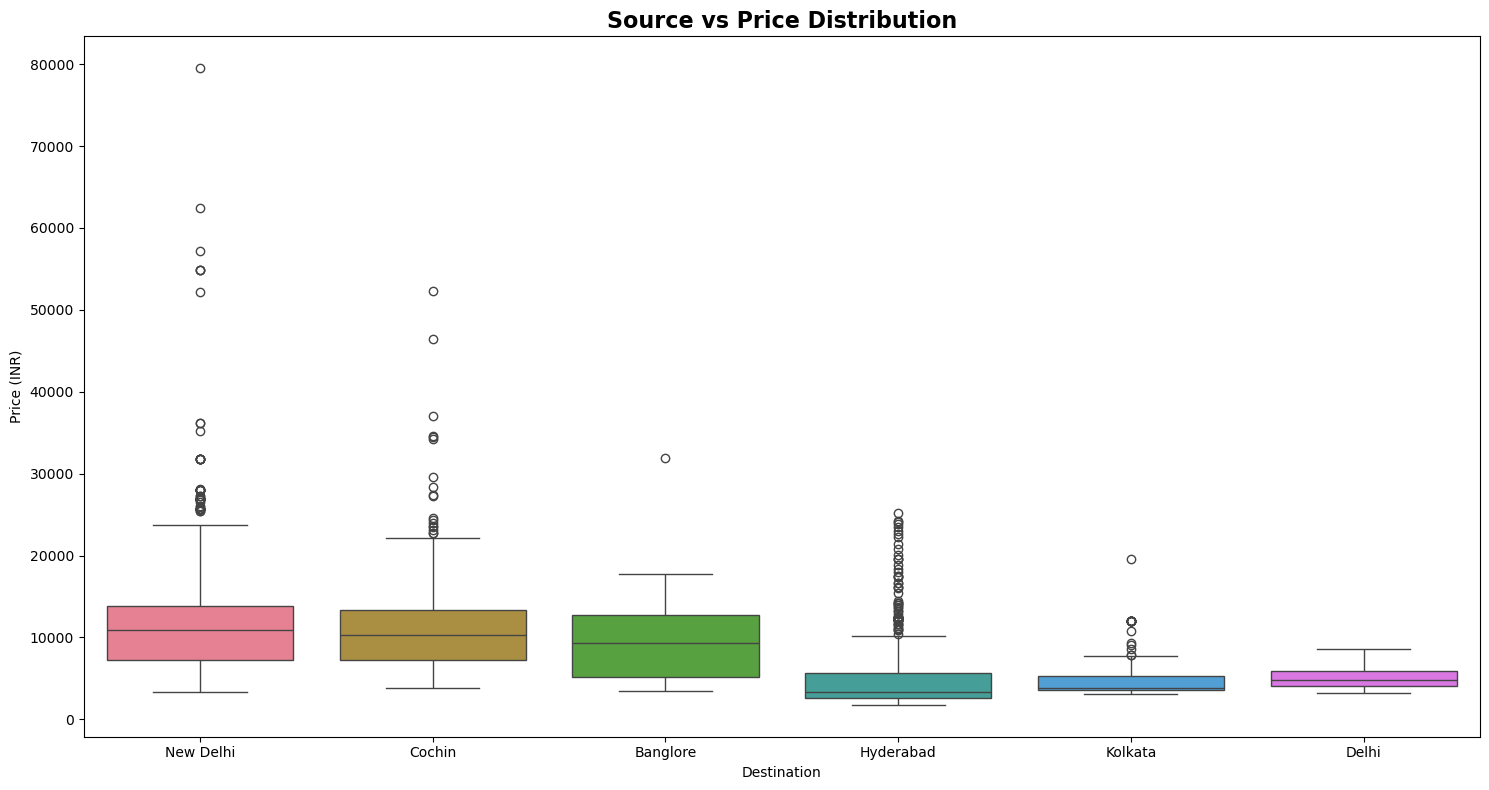

In [66]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Destination',y='Price',data=df.sort_values('Price',ascending=False),palette='husl')
plt.title("Source vs Price Distribution", fontsize=16, fontweight='bold')
plt.ylabel("Price (INR)")
plt.xlabel("Destination")
plt.tight_layout()
plt.show()

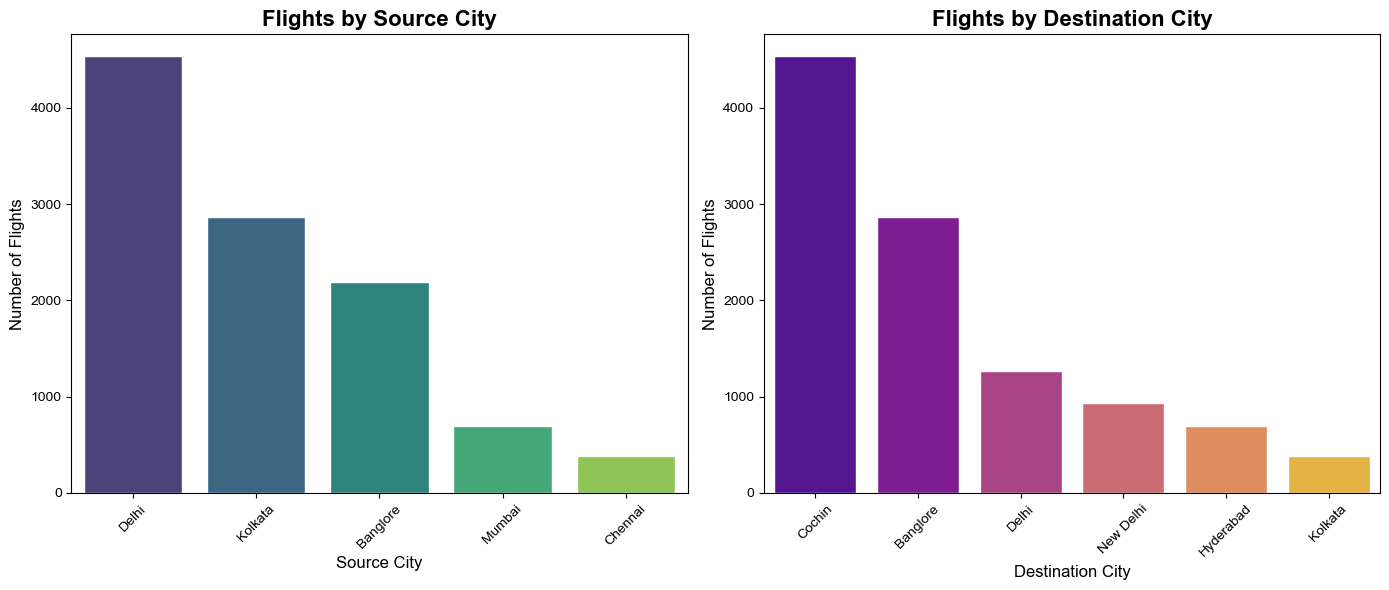

In [67]:
# Value counts for Source and Destination
source_counts = df1['Source'].value_counts()
destination_counts = df1['Destination'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Style settings
sns.set_style("whitegrid")
palette_src = sns.color_palette("viridis", len(source_counts))
palette_dest = sns.color_palette("plasma", len(destination_counts))

# Source plot
sns.barplot(x=source_counts.index, y=source_counts.values, palette=palette_src, ax=axes[0])
axes[0].set_title('Flights by Source City', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Source City', fontsize=12)
axes[0].set_ylabel('Number of Flights', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Destination plot
sns.barplot(x=destination_counts.index, y=destination_counts.values, palette=palette_dest, ax=axes[1])
axes[1].set_title('Flights by Destination City', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Destination City', fontsize=12)
axes[1].set_ylabel('Number of Flights', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Layout
plt.tight_layout()
plt.show()

In [97]:
df

,Airline,Source,Destination,Route,Total_Stops,Price,journey_day,journey_month,Dep_Time_Hour,Dep_Time_Min,Arrival_Time_Hour,Arrival_Time_Min,Hour,Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,7229,27,4,8,20,11,20,3,0
10681,Vistara,Banglore,New Delhi,BLR → DEL,non-stop,12648,1,3,11,30,14,10,2,40


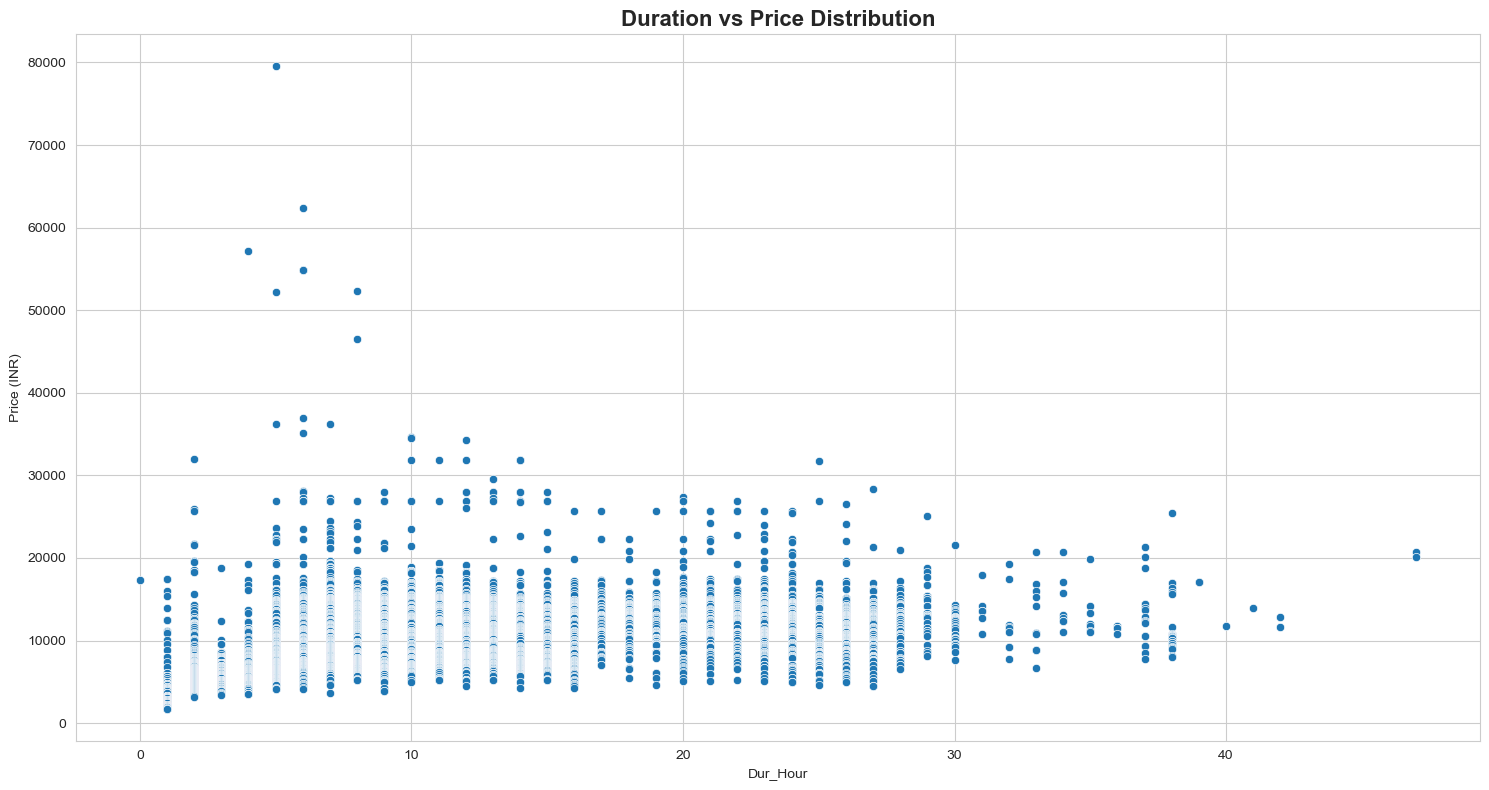

In [119]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='Dur_Hour',y='Price',data=df.sort_values('Price', ascending=False),palette='husl')
plt.title("Duration vs Price Distribution", fontsize=16, fontweight='bold')
plt.ylabel("Price (INR)")
plt.xlabel("Dur_Hour")
plt.tight_layout()
plt.show()

In [ ]:
#encodinhg and scaling

In [ ]:
Airline = pd.get_dummies(df['Airline'],drop_first=True)

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,True,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,True,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,True,False


In [125]:
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [127]:
Source = pd.get_dummies(df['Source'],drop_first=True)

In [129]:
Source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [131]:
Destination = pd.get_dummies(df['Destination'],drop_first=True)

In [132]:
Destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [134]:
df['Route1'] = df['Route'].str.split('→').str[0]
df['Route2'] = df['Route'].str.split('→').str[1]
df['Route3'] = df['Route'].str.split('→').str[2]
df['Route4'] = df['Route'].str.split('→').str[3]
df['Route5'] = df['Route'].str.split('→').str[4]

In [136]:
df.drop('Route',axis=1,inplace=True)

In [138]:
for i in ['Route3','Route4','Route5'] :
    df[i].fillna('None',inplace=True)

In [140]:
encoder = LabelEncoder()

In [141]:
for i in ['Route1','Route2','Route3','Route4','Route5'] :
    df[i]= encoder.fit_transform(df[i])

In [142]:
df.Total_Stops.unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [143]:
dict={'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}
df['Total_Stops']=df['Total_Stops'].map(dict)

In [ ]:
df.drop('Airline',axis=1,inplace=True)
df.drop('Source',axis=1,inplace=True)
df.drop('Destination',axis=1,inplace=True)

In [150]:
df_final=pd.concat([df,Airline,Source,Destination],axis=1)

In [151]:
df_final.head()

,Total_Stops,Price,journey_day,journey_month,Dep_Time_Hour,Dep_Time_Min,Arrival_Time_Hour,Arrival_Time_Min,Dur_Hour,Dur_Minute,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,5,50,13,15,7,25,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,9,25,4,25,19,0,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,18,5,23,30,5,25,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,16,50,21,35,4,45,...,False,False,False,False,False,False,False,False,False,True


In [154]:
df_final['Price']=np.where(df_final['Price']>=40000,df_final['Price'].median(),df_final['Price'])

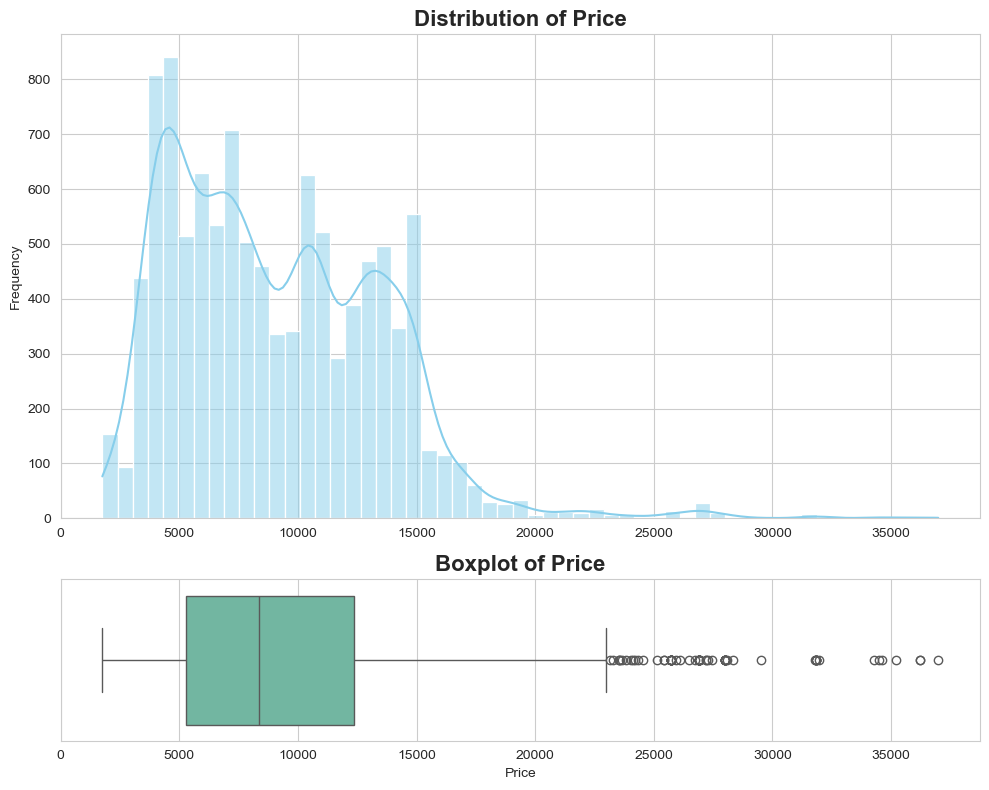

In [155]:
plot(df_final,'Price')

In [ ]:
#Feature selection, model builing, validation

In [158]:
X = df_final.drop('Price',axis=1)
y = df_final['Price']

In [156]:
from sklearn.feature_selection import mutual_info_classif

In [159]:
mutual_info_classif(X,y)

array([1.88804809, 0.89109071, 1.60960519, 1.52398947, 1.29194293,
       1.91206209, 1.6056596 , 1.78218715, 1.13934683, 2.32706932,
       2.97811709, 2.54761208, 1.72849583, 1.46406112, 0.69625047,
       0.07017372, 0.63674431, 0.86109742, 0.00851986, 0.50935799,
       0.02392899, 0.29089651, 0.00415519, 0.20532644, 0.        ,
       0.16415282, 1.34091968, 0.81739328, 0.28852892, 1.35094255,
       0.39760713, 0.28391339, 0.15897832, 0.33776252])

In [160]:
imp_scores = pd.DataFrame(mutual_info_classif(X,y),index=X.columns)
imp_scores

,0
Total_Stops,1.913518
journey_day,0.898902
journey_month,1.655394
Dep_Time_Hour,1.528752
Dep_Time_Min,1.289151
Arrival_Time_Hour,1.882646
Arrival_Time_Min,1.657395
Dur_Hour,1.766508
Dur_Minute,1.126868
Route1,2.330471


In [163]:
imp_scores.columns=['importance']
imp_scores.sort_values(by='importance',ascending=False)

,importance
Route2,2.985936
Route3,2.545394
Route1,2.330471
Total_Stops,1.913518
Arrival_Time_Hour,1.882646
Dur_Hour,1.766508
Route4,1.690474
Arrival_Time_Min,1.657395
journey_month,1.655394
Dep_Time_Hour,1.528752


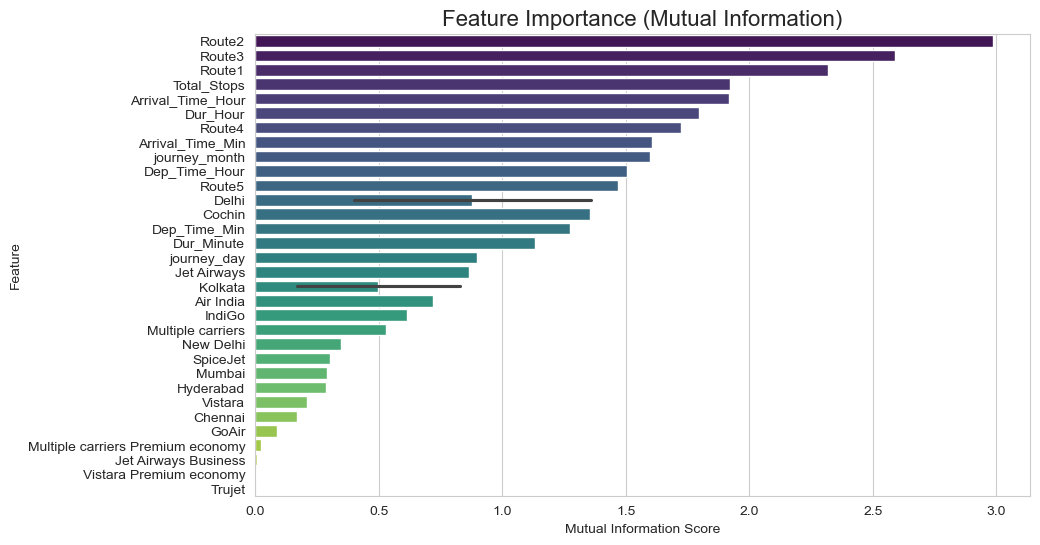

In [164]:
# Calculate MI scores
mi_scores = mutual_info_classif(X, y, discrete_features='auto')

# Create DataFrame
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='MI Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Feature Importance (Mutual Information)', fontsize=16)
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.show()

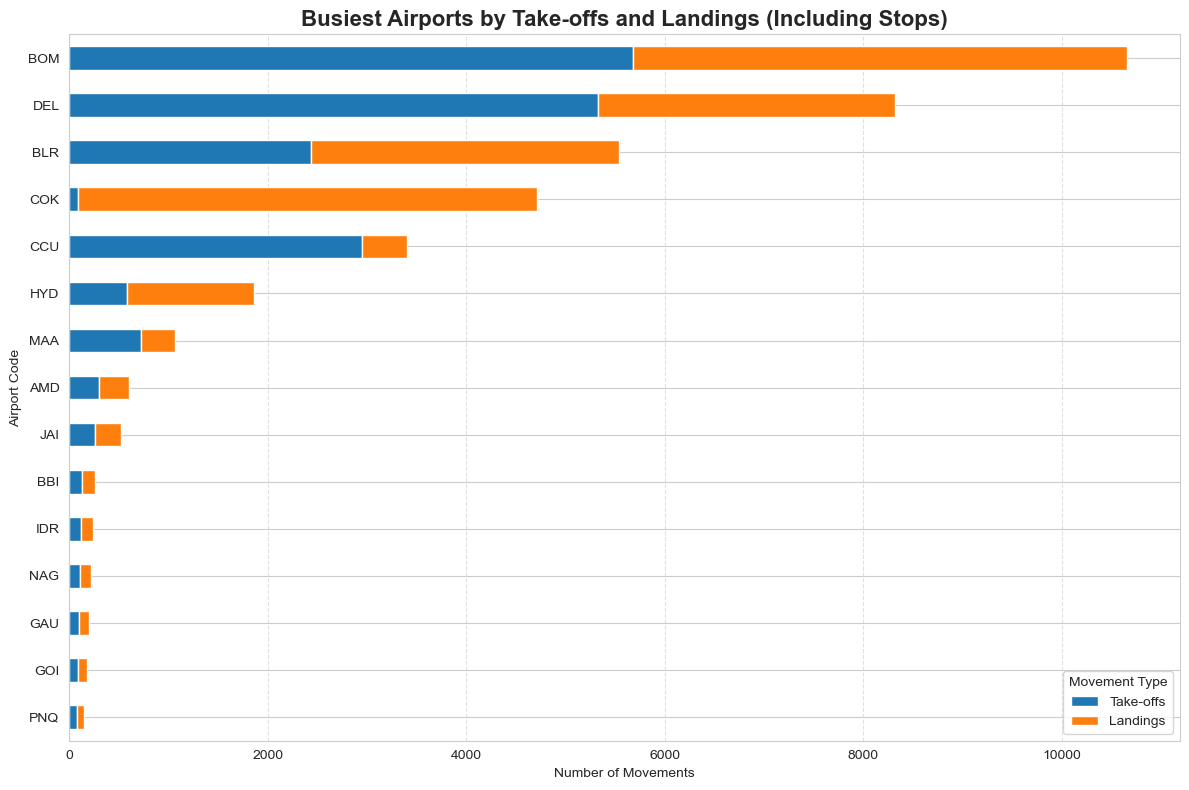

In [165]:
# Helper: split route into list of airports
def split_airports(route):
    if pd.isna(route):  # Skip if NaN
        return []
    return [x.strip() for x in str(route).split('→')]

# Count take-offs and landings
take_off_counts = {}
landing_counts = {}

for route in df1['Route']:
    airports = split_airports(route)
    if not airports:  # Skip empty
        continue

    # First airport = take-off
    take_off_counts[airports[0]] = take_off_counts.get(airports[0], 0) + 1

    # Last airport = landing
    landing_counts[airports[-1]] = landing_counts.get(airports[-1], 0) + 1

    # Intermediate hops: each stop has a landing then a take-off
    for i in range(1, len(airports) - 1):
        landing_counts[airports[i]] = landing_counts.get(airports[i], 0) + 1
        take_off_counts[airports[i]] = take_off_counts.get(airports[i], 0) + 1

# Merge into one DataFrame
airports_df = pd.DataFrame({
    'Take-offs': pd.Series(take_off_counts),
    'Landings': pd.Series(landing_counts)
}).fillna(0)

airports_df['Total Movements'] = airports_df['Take-offs'] + airports_df['Landings']
airports_df = airports_df.sort_values('Total Movements', ascending=False)

# Plot
airports_df.head(15)[['Take-offs', 'Landings']].plot(
    kind='barh', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(12, 8)
)

plt.title('Busiest Airports by Take-offs and Landings (Including Stops)', fontsize=16, weight='bold')
plt.xlabel('Number of Movements')
plt.ylabel('Airport Code')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Movement Type')
plt.tight_layout()
plt.show()


| IATA Code | Full Airport Name                                                                         |
| --------- | ----------------------------------------------------------------------------------------- |
| **BOM**   | Chhatrapati Shivaji Maharaj International Airport — Mumbai         |
| **DEL**   | Indira Gandhi International Airport — Delhi
| **BLR**   | Kempegowda International Airport — Bengaluru
| **COK**   | Cochin International Airport — Kochi
| **CCU**   | Netaji Subhas Chandra Bose International Airport — Kolkata
| **HYD**   | Rajiv Gandhi International Airport — Hyderabad\
| **MAA**   | Chennai International Airport — Chennai
| **AMD**   | Sardar Vallabhbhai Patel International Airport — Ahmedabad
| **JAI**   | Jaipur International Airport — Jaipur
| **BBI**   | Biju Patnaik International Airport — Bhubaneswar
| **NAG**   | Dr. Babasaheb Ambedkar International Airport — Nagpur
| **GAU**   | Lokpriya Gopinath Bordoloi International Airport — Guwahati
| **GOI**   | Goa International Airport (Dabolim) — Goa
| **PNQ**   | Pune Airport — Pune           |
| **IDR**   | Devi Ahilya Bai Holkar Airport — Indore



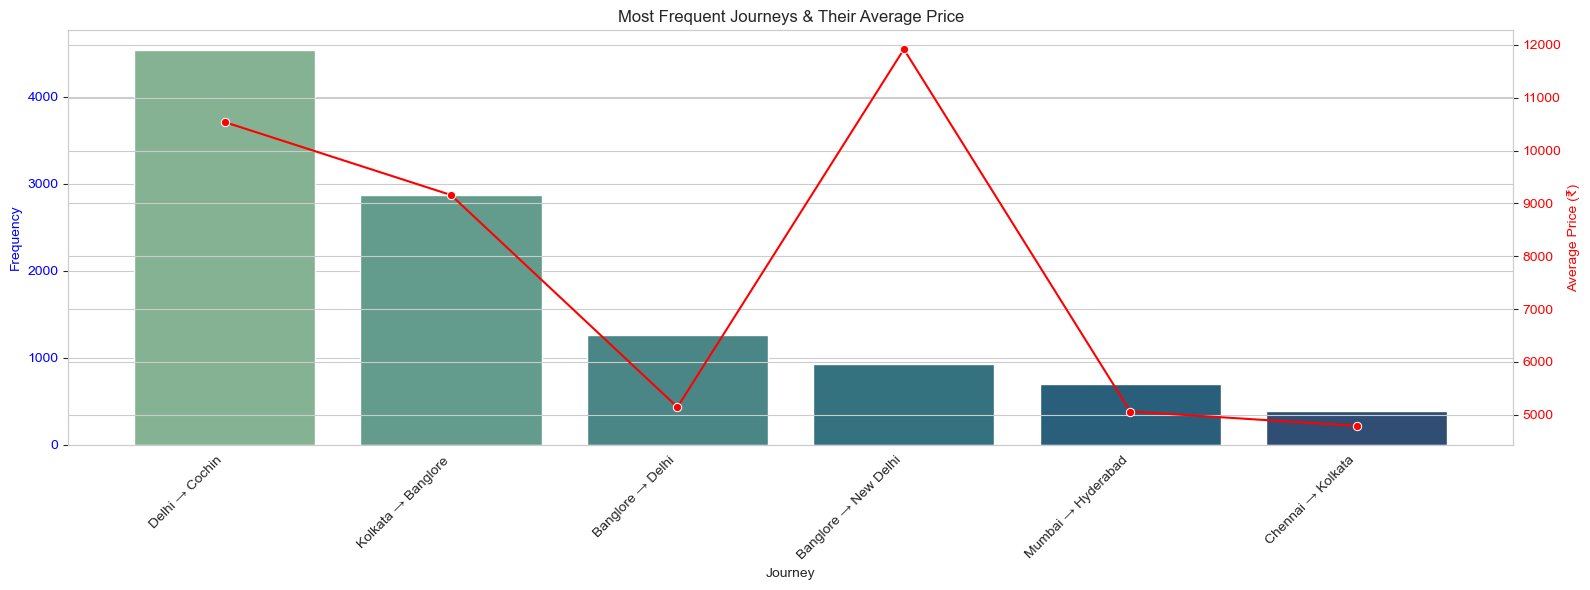

In [167]:
# Create a journey column
df1['Journey'] = df1['Source'] + " → " + df1['Destination']

# Group by journey for count and average price
journey_stats = df1.groupby('Journey').agg(
    Frequency=('Journey', 'size'),
    Avg_Price=('Price', 'mean')
).reset_index()

# Sort by frequency
journey_stats = journey_stats.sort_values(by='Frequency', ascending=False).head(10)

# Plot
fig, ax1 = plt.subplots(figsize=(16,6))

# Bar plot for frequency
sns.barplot(data=journey_stats, x='Journey', y='Frequency', palette='crest', ax=ax1)
ax1.set_ylabel('Frequency', color='b')
ax1.set_xlabel('Journey')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary axis for average price
ax2 = ax1.twinx()
sns.lineplot(data=journey_stats, x='Journey', y='Avg_Price', marker='o', color='r', ax=ax2)
ax2.set_ylabel('Average Price (₹)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Most Frequent Journeys & Their Average Price")
plt.tight_layout()
plt.show()

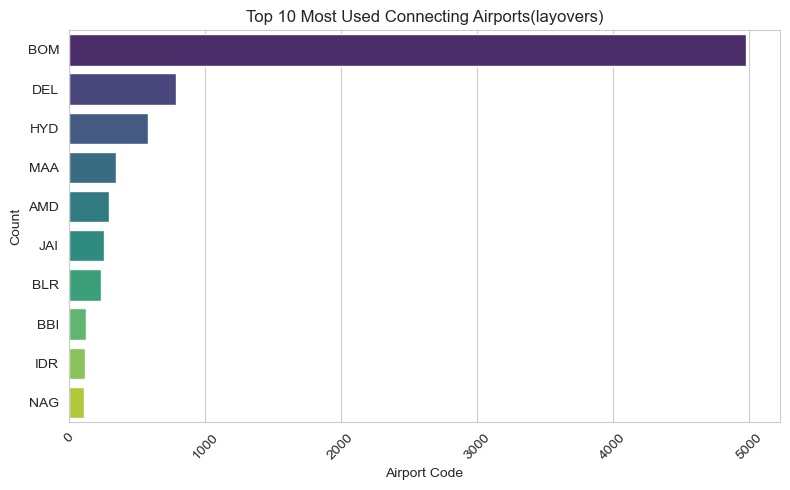

In [168]:
from collections import Counter


# Remove NaN and split routes
all_stops = df1['Route'].dropna().apply(lambda x: x.split(' → '))

# Count intermediate stops
connecting_airports = Counter()
for route in all_stops:
    if len(route) > 2:  # has at least 1 connecting airport
        connecting_airports.update(route[1:-1])

# Create dataframe of top 10
top_connecting = connecting_airports.most_common(10)
connecting_df = pd.DataFrame(top_connecting, columns=['Airport', 'Count'])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=connecting_df, x='Count', y='Airport', palette='viridis')
plt.title("Top 10 Most Used Connecting Airports(layovers)")
plt.xlabel("Airport Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

IATA Code for reference

| IATA Code | Full Airport Name                                                                         |
| --------- | ----------------------------------------------------------------------------------------- |
| **BOM**   | Chhatrapati Shivaji Maharaj International Airport — Mumbai         |
| **DEL**   | Indira Gandhi International Airport — Delhi
| **BLR**   | Kempegowda International Airport — Bengaluru
| **COK**   | Cochin International Airport — Kochi
| **CCU**   | Netaji Subhas Chandra Bose International Airport — Kolkata
| **HYD**   | Rajiv Gandhi International Airport — Hyderabad\
| **MAA**   | Chennai International Airport — Chennai
| **AMD**   | Sardar Vallabhbhai Patel International Airport — Ahmedabad
| **JAI**   | Jaipur International Airport — Jaipur
| **BBI**   | Biju Patnaik International Airport — Bhubaneswar
| **NAG**   | Dr. Babasaheb Ambedkar International Airport — Nagpur
| **GAU**   | Lokpriya Gopinath Bordoloi International Airport — Guwahati
| **GOI**   | Goa International Airport (Dabolim) — Goa
| **PNQ**   | Pune Airport — Pune           |
| **IDR**   | Devi Ahilya Bai Holkar Airport — Indore



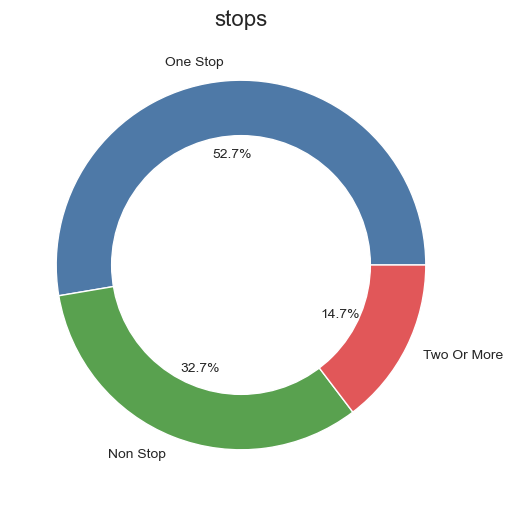

In [169]:
# Example stop counts (replace these with your actual data counts)
stop_counts = [
    (df1['Total_Stops'] == '1 stop').sum(),          # One Stop
    (df1['Total_Stops'] == 'non-stop').sum(),        # Zero Stops
    (df1['Total_Stops'].isin(['2 stops', '3 stops'])).sum()  # Two Or More
]

labels = ['One Stop', 'Non Stop', 'Two Or More']
colors = ['#4e79a7', '#59a14f', '#e15759']

# Donut chart
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    stop_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'width': 0.4}
)

# Add center circle
plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='white'))

plt.title("stops", fontsize=16)
plt.show()

In [ ]:
#model training

In [180]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor

In [172]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123)

In [173]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
def predict(ml_model):
    print('Model is: {}'.format(ml_model))
    model= ml_model.fit(X_train,y_train)
    print("Training score: {}".format(model.score(X_train,y_train)))
    predictions = model.predict(X_test)
    print("Predictions are: {}".format(predictions))
    print('\n')
    r2score=r2_score(y_test,predictions)
    print("r2 score is: {}".format(r2score))

    print('MAE:{}'.format(mean_absolute_error(y_test,predictions)))
    print('MSE:{}'.format(mean_squared_error(y_test,predictions)))
    print('RMSE:{}'.format(np.sqrt(mean_squared_error(y_test,predictions))))

    sns.distplot(y_test-predictions)

Model is: LinearRegression()
Training score: 0.6175384347965833
Predictions are: [ 9674.79440213 13441.69196361 11654.56701631 ...  6783.83924662
  6456.49896288 12445.07362614]


r2 score is: 0.6352053691461463
MAE:1845.2097304809788
MSE:6536373.206550482
RMSE:2556.633177941349


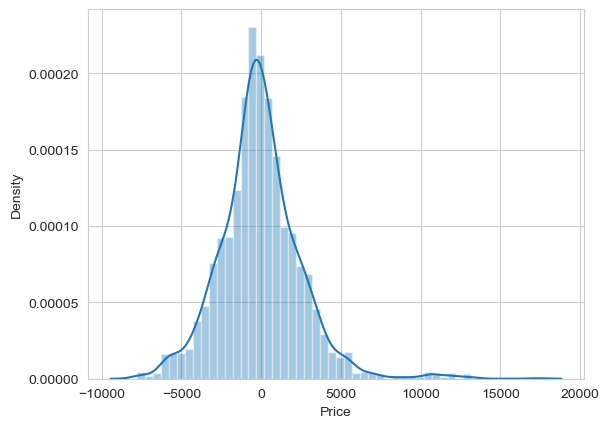

In [175]:
predict(LinearRegression())

Model is: KNeighborsRegressor()
Training score: 0.7797715942621029
Predictions are: [ 8355.4 16362.4 12933.2 ...  3757.   8408.  11232.4]


r2 score is: 0.6655296078645999
MAE:1640.7559195133365
MSE:5993024.909443145
RMSE:2448.0655443519368


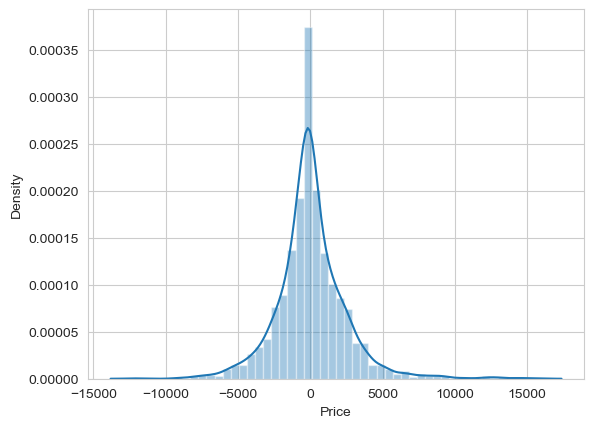

In [176]:
predict(KNeighborsRegressor())

Model is: DecisionTreeRegressor()
Training score: 0.9667772510524137
Predictions are: [ 8996. 18550. 14571. ...  3717.  6069. 10262.]


r2 score is: 0.7319630322031208
MAE:1223.145141163625
MSE:4802673.9060598975
RMSE:2191.500377837042


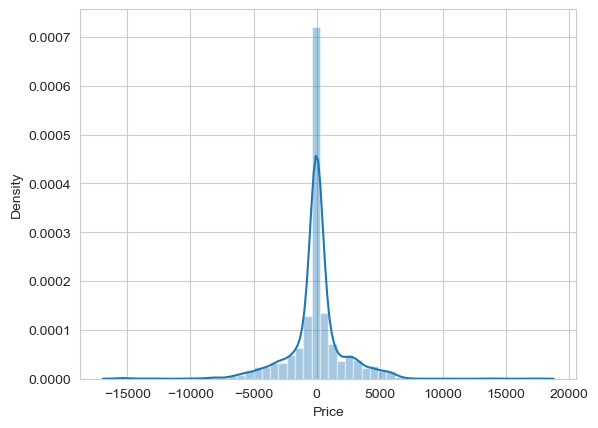

In [177]:
predict(DecisionTreeRegressor())

Model is: RandomForestRegressor()
Training score: 0.9523236512835181
Predictions are: [ 8741.7175     17386.47       13885.74966667 ...  3823.56
  5734.96       10547.89      ]


r2 score is: 0.8358342556177625
MAE:1081.807026793827
MSE:2941514.162370894
RMSE:1715.0843018262672


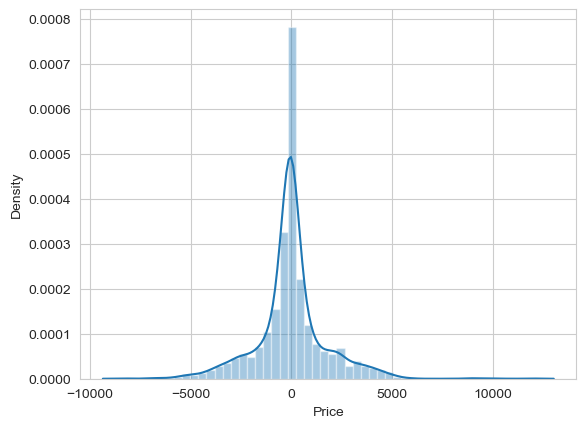

In [178]:
predict(RandomForestRegressor())

Model is: GradientBoostingRegressor()
Training score: 0.7933529715528734
Predictions are: [ 5304.62350438 17247.90864471 11919.44380805 ...  4554.09160992
  6449.13234004 11915.85278629]


r2 score is: 0.7979836825125275
MAE:1419.3419759828687
MSE:3619718.9685067455
RMSE:1902.555904173842


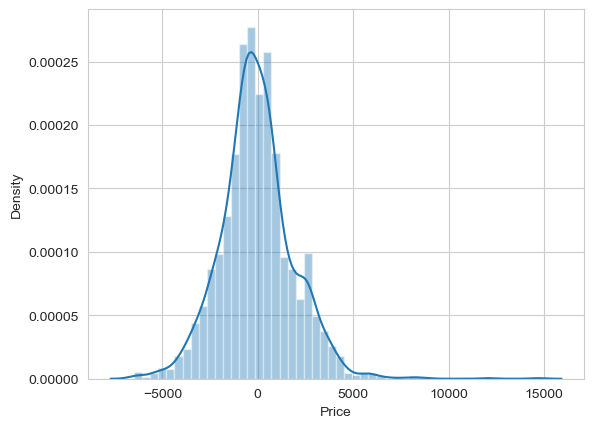

In [179]:
predict(GradientBoostingRegressor())

In [184]:
X1 = X.copy()
y1 = y.copy()
# predict(XGBRegressor())

In [ ]:
#hyper tuning the model

In [185]:
from sklearn.model_selection import RandomizedSearchCV

In [186]:
random_grid = {
    'n_estimators' : [100, 120, 150, 180, 200,220],
    'max_features':['auto','sqrt'],
    'max_depth':[5,10,15,20],
}

In [187]:
rf=RandomForestRegressor()
rf_random=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,cv=3,verbose=2,n_jobs=-1,)

rf_random.fit(X_train,y_train)

# best parameter
rf_random.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 120, 'max_features': 'sqrt', 'max_depth': 15}

0.8400484737030502

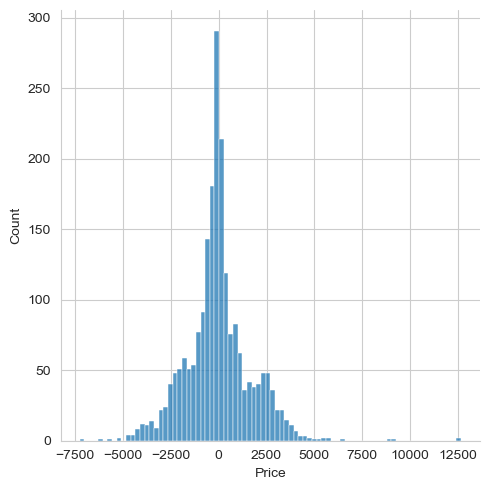

In [188]:
#predicting the values
prediction = rf_random.predict(X_test)

#distribution plot between actual value and predicted value
sns.displot(y_test-prediction)

#r2_score
r2_score(y_test,prediction)

In [190]:
# Assuming X_train and y_train are your preprocessed training dataframes

# 1. Define the model you want to tune
rf_model = RandomForestRegressor(random_state=42)

# 2. Define the parameter grid to search through
# These are some common hyperparameters for RandomForest
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees in the forest
    'max_depth': [10, 15, 20, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4]       # Minimum number of samples required at each leaf node
}

# 3. Set up the GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='r2' specifies that we want to optimize for the R-squared score
# n_jobs=-1 uses all available CPU cores to speed up the search
# verbose=2 will print progress updates as it runs
grid_search = GridSearchCV(estimator=rf_model, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='r2', 
                           n_jobs=-1, 
                           verbose=2)

# 4. Fit the grid search to your training data
# This will start the search process
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV finished.")

# 5. Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n----------------------------------")
print(f"Best Hyperparameters found: {best_params}")
print(f"Best R^2 score from Cross-Validation: {best_score:.4f}")
print("----------------------------------")

# You can now use the best estimator for predictions
best_rf_model = grid_search.best_estimator_

Starting GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV finished.

----------------------------------
Best Hyperparameters found: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best R^2 score from Cross-Validation: 0.8353
----------------------------------
